# Generate memorized CIFAR-10 samples

Samples up to `top_k` local images from the finetuned CIFAR-10 DDPM, confirms each is memorized
(pixel-space nearest-neighbor ratio against its finetuning subset), and saves them for
`02_fr_guidance.ipynb` to pick a starting point from.

Draws fresh local samples rather than reusing the cluster's flagged ones: `torch.Generator`
produces a different stream per device backend even for the same seed, so a CUDA-generated
sample can't be reproduced locally. Everything here stays on one device, so a winning seed
reproduces bit-exactly in `02_fr_guidance.ipynb`.

`train_idx.npy` isn't downloaded -- `finetune_cifar10_ddpm.py` builds it deterministically, so
it's regenerated here.

In [ ]:
import os, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from diffusers import UNet2DModel, DDPMScheduler

# cifar10_data.py / assess_memorization_cifar10.py live alongside this notebook
sys.path.insert(0, os.path.abspath("."))
from cifar10_data import load_cifar10
from assess_memorization_cifar10 import nearest_neighbor_d1_d2, classify_images

# assess_memorization_cifar10 sets matplotlib to Agg on import; re-assert inline here
%matplotlib inline


In [ ]:
config = {
    "device": os.environ.get("DEVICE", "cpu"),
    "pretrained_dir": "pretrained/ddpm-cifar10-32",
    "score_ckpt_path": "trained_data/ddpm_finetuned.pt",
    "cifar10_data_dir": "../../data/cifar-10-batches-py",
    "output_dir": "checkpoints",
    "finetune_seed": 0,       # matches finetune_cifar10_ddpm.py's config["seed"]
    "n_train": 1000,          # matches finetune_cifar10_ddpm.py's N_TRAIN
    "mem_ratio_threshold": 5 / 10,   # looser than the assess script's default (1/3): CIFAR-10 at
                                        # 32x32 rarely gives a crisp near-exact copy even when
                                        # memorized, so a looser cutoff surfaces more candidates
    "n_steps": 1000,           # matches sample_cifar10.py's N_STEPS_EVAL
    "seed_trials": list(range(50)),
    "top_k": 5,                # stop early once this many memorized candidates are found
}
OUT_DIR = "checkpoints"
os.makedirs(OUT_DIR, exist_ok=True)
print(config)

## Training subset + frozen model

Reconstructs the exact 1000-image subset the model was finetuned on, then loads the finetuned UNet + its DDPM scheduler.

In [3]:
images, _ = load_cifar10(data_dir=config["cifar10_data_dir"], split="train")
rng = np.random.default_rng(config["finetune_seed"])
train_idx = rng.choice(len(images), size=config["n_train"], replace=False)
X_train = images[train_idx].to(config["device"])
X_train_flat = X_train.reshape(X_train.shape[0], -1)
print(f"reconstructed train_idx: {train_idx.shape}, X_train: {X_train.shape}")


reconstructed train_idx: (1000,), X_train: torch.Size([1000, 3, 32, 32])


In [4]:
net = UNet2DModel.from_pretrained(config["pretrained_dir"]).to(config["device"])
score_ckpt = torch.load(config["score_ckpt_path"], map_location=config["device"])
net.load_state_dict(score_ckpt.get("model_ema", score_ckpt["model"]))
net.eval()
for p in net.parameters():
    p.requires_grad_(False)

scheduler = DDPMScheduler.from_pretrained(config["pretrained_dir"])
print(f"loaded finetuned UNet from {config['score_ckpt_path']} (using "
      f"{'EMA' if 'model_ema' in score_ckpt else 'raw'} weights, "
      f"trained {score_ckpt['iter'] + 1} iterations)")


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


loaded finetuned UNet from trained_data/ddpm_finetuned.pt (using EMA weights, trained 20000 iterations)


## Sampling + memorization check

`sample_one` mirrors `sample_cifar10.py`'s `sample()` exactly (same ancestral DDPM reverse loop), restricted to a single image. `mem_ratio` reuses `assess_memorization_cifar10.py`'s own `nearest_neighbor_d1_d2`/`classify_images` so "memorized" here means the same thing it means everywhere else in this project.

In [5]:
@torch.no_grad()
def sample_one(seed, n_steps):
    scheduler.set_timesteps(n_steps)
    generator = torch.Generator(device=config["device"]).manual_seed(seed)
    x = torch.randn(1, 3, 32, 32, device=config["device"], generator=generator)
    for t in scheduler.timesteps:
        eps_hat = net(x, t).sample
        x = scheduler.step(eps_hat, t, x, generator=generator).prev_sample
    return x.clamp(-1, 1)


def eval_memorization(x_single):
    x_flat = x_single.reshape(1, -1)
    d1, d2, nn_idx = nearest_neighbor_d1_d2(x_flat, X_train_flat)
    ratio = (d1 / d2).item()
    is_memorized = ratio < config["mem_ratio_threshold"]
    return {"d1": d1.item(), "d2": d2.item(), "ratio": ratio,
            "nn_idx": int(nn_idx.item()), "is_memorized": is_memorized}


## Search for memorized seeds

Runs `sample_one` at full `n_steps=1000` across `seed_trials`, keeping results that clear
`mem_ratio_threshold`, up to `top_k` candidates.

Screening at a cheaper `n_steps` first doesn't work: `scheduler.set_timesteps(n_steps)` picks a
different strided schedule per `n_steps`, so runs at different resolutions only share their
initial noise -- everything downstream diverges. Full resolution, every attempt.

In [6]:
candidates = []
for seed in config["seed_trials"]:
    t0 = time.time()
    x = sample_one(seed, config["n_steps"])
    stats = eval_memorization(x)
    print(f"seed={seed}: ratio={stats['ratio']:.3f} memorized={stats['is_memorized']} "
          f"nn_idx={stats['nn_idx']} ({time.time() - t0:.1f}s)")
    if stats["is_memorized"]:
        candidates.append({"seed": seed, "x_single": x.cpu(), **stats})
        if len(candidates) >= config["top_k"]:
            break

if not candidates:
    raise RuntimeError("no seed in seed_trials memorized at n_steps -- widen seed_trials or "
                        "loosen mem_ratio_threshold")

candidates.sort(key=lambda r: r["ratio"])
print(f"\nfound {len(candidates)} memorized candidate(s): "
      f"{[(c['seed'], round(c['ratio'], 3)) for c in candidates]}")


seed=0: ratio=0.990 memorized=False nn_idx=274 (40.9s)
seed=1: ratio=0.663 memorized=False nn_idx=930 (40.1s)
seed=2: ratio=0.981 memorized=False nn_idx=817 (42.6s)
seed=3: ratio=0.863 memorized=False nn_idx=339 (43.9s)
seed=4: ratio=0.997 memorized=False nn_idx=70 (68.2s)
seed=5: ratio=0.667 memorized=False nn_idx=558 (76.1s)
seed=6: ratio=0.929 memorized=False nn_idx=339 (76.9s)
seed=7: ratio=0.959 memorized=False nn_idx=543 (76.4s)
seed=8: ratio=0.853 memorized=False nn_idx=374 (78.6s)
seed=9: ratio=0.208 memorized=True nn_idx=458 (62.6s)
seed=10: ratio=0.592 memorized=False nn_idx=590 (77.8s)
seed=11: ratio=0.957 memorized=False nn_idx=336 (79.8s)
seed=12: ratio=0.213 memorized=True nn_idx=783 (78.3s)
seed=13: ratio=0.308 memorized=True nn_idx=595 (79.4s)
seed=14: ratio=0.977 memorized=False nn_idx=624 (76.9s)
seed=15: ratio=0.786 memorized=False nn_idx=576 (78.8s)
seed=16: ratio=0.996 memorized=False nn_idx=339 (77.7s)
seed=17: ratio=0.908 memorized=False nn_idx=239 (55.4s)
seed=1

## Candidates vs. their nearest training image

One row per candidate (best ratio first) so you can pick which one to carry into `02_fr_guidance.ipynb`.

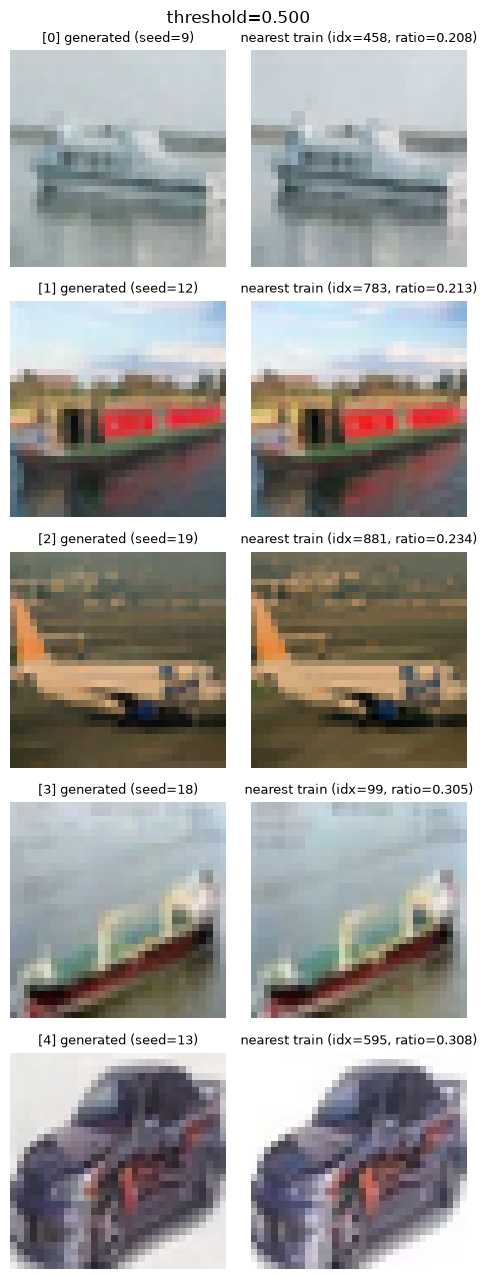

In [7]:
n_show = len(candidates)
fig, axes = plt.subplots(n_show, 2, figsize=(5, 2.6 * n_show), squeeze=False)
for row, c in enumerate(candidates):
    nn_image = X_train[c["nn_idx"]]
    axes[row, 0].imshow(((c["x_single"][0] + 1) / 2).permute(1, 2, 0).clamp(0, 1))
    axes[row, 0].set_title(f"[{row}] generated (seed={c['seed']})", fontsize=9)
    axes[row, 1].imshow(((nn_image.cpu() + 1) / 2).permute(1, 2, 0).clamp(0, 1))
    axes[row, 1].set_title(f"nearest train (idx={c['nn_idx']}, ratio={c['ratio']:.3f})", fontsize=9)
    for ax in axes[row]:
        ax.axis("off")
fig.suptitle(f"threshold={config['mem_ratio_threshold']:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "candidates_vs_nn.png"), dpi=150)
plt.show()


## Save all candidates for `02_fr_guidance.ipynb`

Saves each candidate's `seed`+`n_steps` (re-running `sample_one` reproduces `x_single`
bit-exactly), plus its image and nearest-training match. Set `CANDIDATE_INDEX` in the next
notebook to whichever row looked best.

In [8]:
torch.save({
    "candidates": [
        {"seed": c["seed"], "n_steps": config["n_steps"], "x_single": c["x_single"],
         "nn_train_idx": c["nn_idx"], "d1": c["d1"], "d2": c["d2"], "ratio": c["ratio"]}
        for c in candidates
    ],
    "device": config["device"],
    "train_idx": train_idx,   # so 02_fr_guidance.ipynb doesn't have to recompute X_train's identity
    "mem_ratio_threshold": config["mem_ratio_threshold"],
}, os.path.join(OUT_DIR, "single_sample.pt"))
print(f"saved {len(candidates)} candidate(s) to {OUT_DIR}/single_sample.pt")


saved 5 candidate(s) to checkpoints/single_sample.pt
